# FITS Imaging — Version 2.2 cleaned driver notebook

This notebook keeps interactive work in Jupyter while moving reusable code into the `fits_imaging` package. The package functions are written so they can later be used by a command-line program or GUI.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from fits_imaging.config import ImagingConfig
from fits_imaging.fits_io import choose_file
from fits_imaging.analysis import analyze_fits_file
from fits_imaging.report import print_image_summary, print_peak_table
from fits_imaging.plotting import (
    plot_image_with_peaks,
    plot_peak_cutouts,
    plot_histogram,
)

config = ImagingConfig()
config


ImagingConfig(data_root=PosixPath('/Users/svwbeckwith/Dropbox/CuRIOS/Software/DataDirectories'), zero_mag_counts=115000000, pixel_arcsec=1.24, threshold_sigma=5.0, max_peaks=1000, peak_separation=10.0, contrast_method='sigma', contrast_percentiles=(1.0, 99.8), contrast_sigma_low=1.0, contrast_sigma_high=5.0, stretch='linear', colormap='viridis', invert_colormap=False, invert_gray=False, histogram_max_points=2000000, histogram_bins=200)

## Select a FITS file

Set `data_root` to your top-level `DataDirectories` folder. `choose_file()` now handles either case: a folder containing FITS files directly, or a folder containing subdirectories of FITS files.


In [3]:
config = ImagingConfig()
image_path = choose_file(config.data_root, extensions=(".fits", ".fit"))
image_path


Directory#   Directory
----------------------------------------------------------------------
    0       Archive
    1       CowTests
    2       Images
    3       Lib-0610
    4       Patio-0629
    5       Patio-0703
----------------------------------------------------------------------


Choose directory number:  4



File#       File
----------------------------------------------------------------------
    0       Altair-Bahtinov_2026-06-29_08.15.59_CuED-0.fits
    1       Altair-Bahtinov_2026-06-29_08.15.59_CuED_0_sum.fits
    2       Altair-Bahtinov_2026-06-29_08.21.48_CuED-0.fits
    3       Altair-Bahtinov_2026-06-29_08.26.49_CuED-0.fits
    4       M15_2026-06-29_10.20.58_CuED_10_sum.fits
    5       M57_2026-06-29_10.06.46_CuED_5_sum.fits
    6       M71_2026-06-29_10.11.32_CuED_10_sum.fits
    7       Neptune_2026-06-29_10.30.12_CuED-0.fits
    8       Neptune_2026-06-29_10.30.12_CuED_4_sum.fits
    9       Neptune_2026-06-29_10.40.37_CuED-0.fits
   10       Neptune_2026-06-29_10.40.37_CuED_4_sum.fits
   11       Polaris_2026-06-29_08.56.03_CuED_5_sum.fits
   12       Polaris_2026-06-29_08.59.05_CuED-0.fits
   13       Saturn_2026-06-29_10.45.04_CuED-0.fits
   14       Saturn_2026-06-29_10.45.04_CuED_9_sum.fits
   15       Vega-Bahtinov_2026-06-29_09.26.41_CuED-0.fits
   16       VegaBC_20

Enter file number to analyze:  9


PosixPath('/Users/svwbeckwith/Dropbox/CuRIOS/Software/DataDirectories/Patio-0629/Neptune_2026-06-29_10.40.37_CuED-0.fits')

## Read image and find peaks

In [5]:
record, imagec, peaksarray, stats = analyze_fits_file(
    image_path,
    peak_separation=10.0,
    peak_sharp=0.2,
    maxsources=400,
    fit_method='gaussian',   # use 'moments' for faster center-of-light estimates
)

print_image_summary(record, imagec, stats)

Neptune  9576 x 6380  Apx60-CuED  2.513 sec
RAH:   0.283  Dec:   0.348  PA: 315.64  PA2:  44.36  Alt:    31.5  Az:   117.8
Mean: 302.5  Median: 301.0  Std: 29.8  Min: 91.0  Max: 37624.0
Found 98 peaks in 2.76 sec


## Full image with labeled peaks

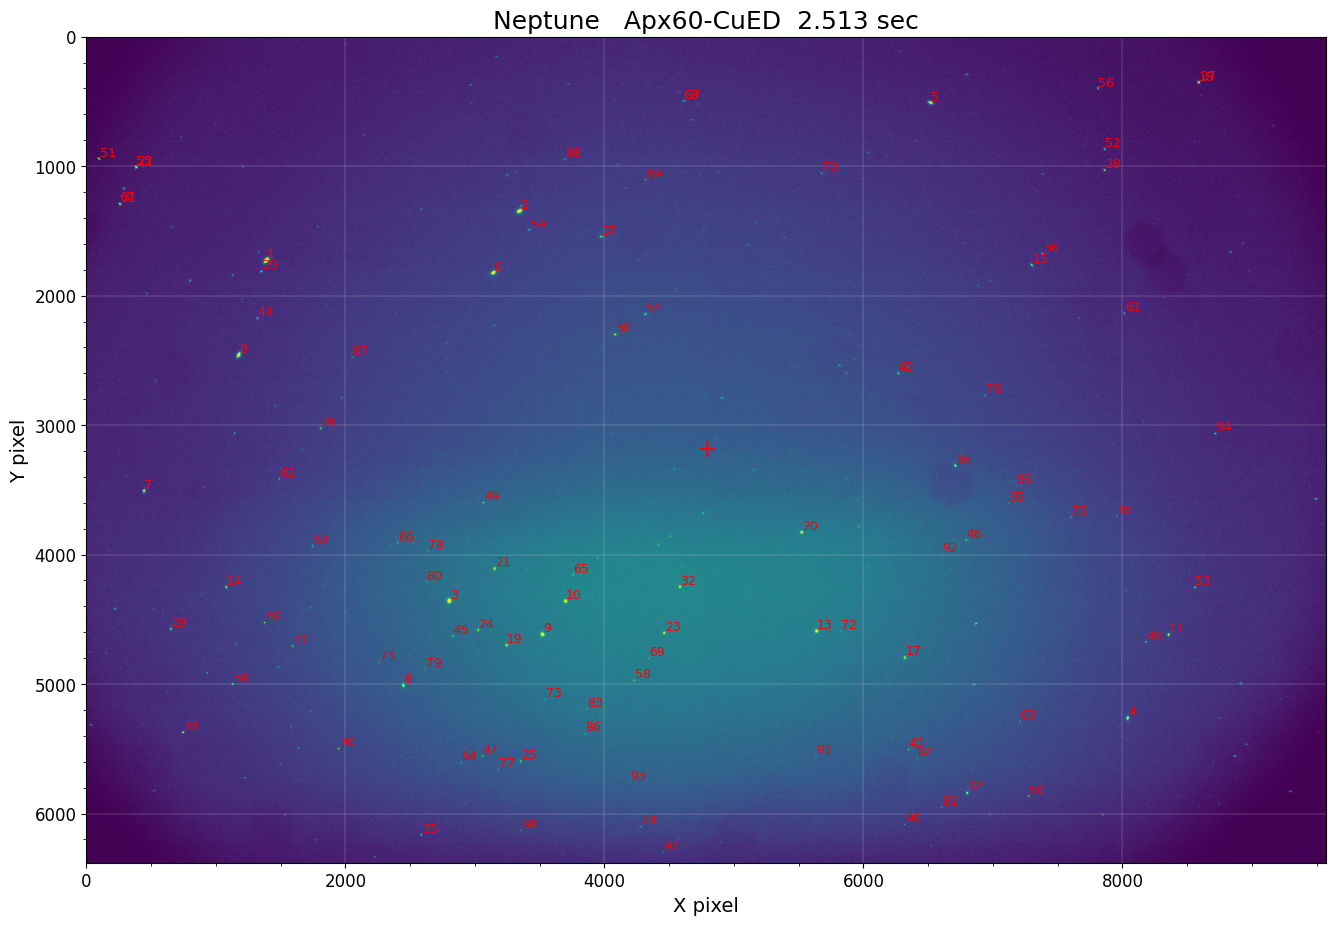

In [7]:
title = f'{record.object_name}   {record.camera}  {record.exposure_sec:.3f} sec'
fig, ax = plot_image_with_peaks(
    imagec,
    peaksarray,
    title=title,
    figsize=(16, 16),
    config=config,
)
plt.show()

## Peak table

In [9]:
swarpfac = -1.0 if record.softname == 'SWarp' else 1.0
print_peak_table(
    peaksarray,
    exposure_sec=record.exposure_sec,
    zero_mag_counts=config.zero_mag_counts,
    pa0=record.pa_deg,
    swarpfac=swarpfac,
    max_rows=200,
)


Peak#        X        Y        Area       sx      sy        Flux      Mag
------------------------------------------------------------------------------
    0   1177.55   2458.14    613561.6    3.93    3.46    412565.0    7.113
    1   1392.36   1726.46    408838.0    4.29    4.66    221865.0    7.787
    2   3345.88   1348.74    223432.6    3.11    2.13    189235.0    7.960
    3   2804.54   4357.14    167160.5    1.38    2.54    155481.0    8.173
    4   8045.11   5260.66    213413.9    3.72    3.00    151463.0    8.201
    5   6522.11    511.26    189935.2    3.53    3.28    138421.0    8.299
    6   3144.93   1824.45    147813.7    2.67    2.34    137781.0    8.304
    7    447.36   3507.63    172392.4    5.16    3.04     89506.0    8.773
    8   2450.95   5010.83     86552.6    1.62    2.08     86442.0    8.810
    9   3524.00   4615.77     75465.9    1.81    2.45     77563.0    8.928
   10   3702.84   4360.11     73996.7    2.28    2.72     69531.0    9.047
   11   8360.88   461

## Peak cutouts

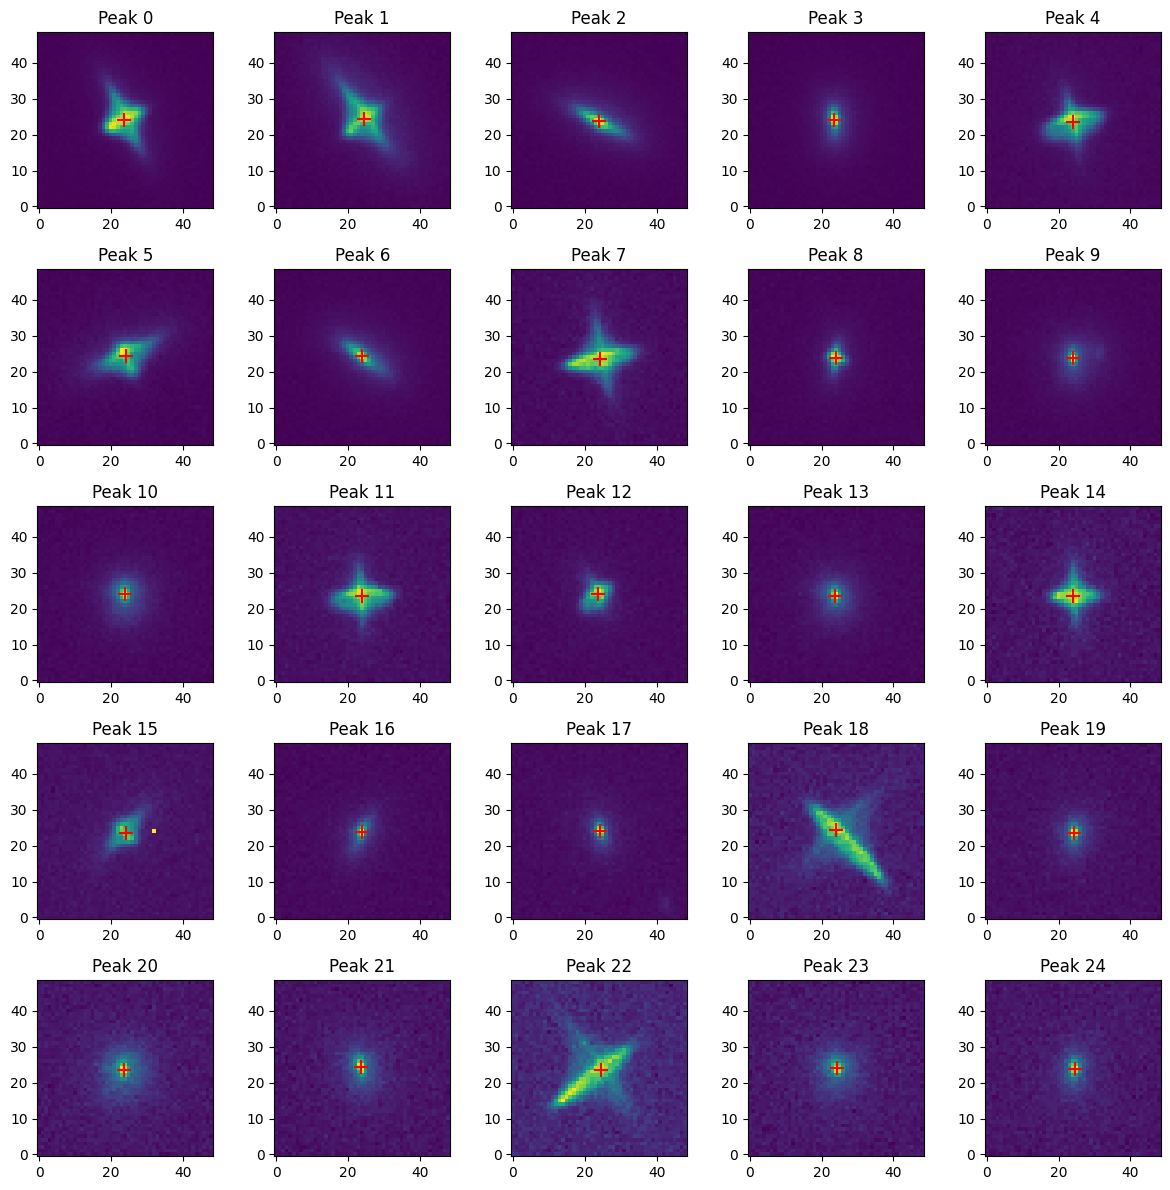

In [13]:
if len(peaksarray) > 0:
    fig, axs = plot_peak_cutouts(
        imagec,
        peaksarray,
        nmax=25,
        spansize=48,
        pixel_arcsec=config.pixel_arcsec,
        exposure_sec=record.exposure_sec,
        zero_mag_counts=config.zero_mag_counts,
    )
    plt.show()
else:
    print('No peaks found.')

## Optional diagnostic plots

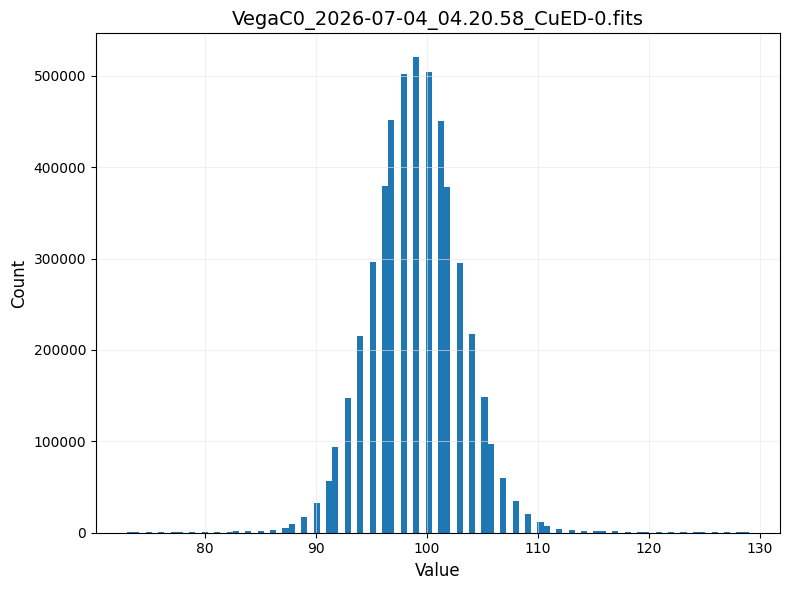

In [13]:
fig, ax = plot_histogram(imagec, title=record.filename)
plt.show()

In [ ]:
convolved_image, fig, ax = plot_convolved_image(imagec, title=f'{record.filename}: W5x5 convolution')
plt.show()